# Smart Home Network Analytics — Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os

# ---------- Dark theme setup ----------
BG = '#1a1a2e'
PRIMARY = '#e94560'
SECONDARY = '#0f3460'
TERTIARY = '#16213e'
TEXT = 'white'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': TERTIARY,
    'axes.edgecolor': TEXT,
    'axes.labelcolor': TEXT,
    'text.color': TEXT,
    'xtick.color': TEXT,
    'ytick.color': TEXT,
    'grid.color': '#2a2a4a',
    'grid.alpha': 0.4,
    'legend.facecolor': TERTIARY,
    'legend.edgecolor': TEXT,
    'legend.labelcolor': TEXT,
    'figure.figsize': (12, 6),
    'font.size': 12,
    'savefig.facecolor': BG,
    'savefig.dpi': 300,
})

# ---------- Ensure images directory exists ----------
os.makedirs('../images', exist_ok=True)

# ---------- Load data ----------
households = pd.read_csv('../data/households.csv')
events = pd.read_csv('../data/network_events.csv')
sessions = pd.read_csv('../data/user_sessions.csv')

# Parse dates
households['signup_date'] = pd.to_datetime(households['signup_date'])
events['date'] = pd.to_datetime(events['date'])
sessions['date'] = pd.to_datetime(sessions['date'])

print('Households:', households.shape)
print('Network Events:', events.shape)
print('User Sessions:', sessions.shape)
print('\nAll datasets loaded successfully.')

/Users/harthikmallichetty/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Households: (5000, 10)
Network Events: (450000, 7)
User Sessions: (373313, 6)

All datasets loaded successfully.


## Dataset Overview

In [2]:
# ---------- Households ----------
print('=' * 60)
print('HOUSEHOLDS')
print('=' * 60)
print(f'Shape: {households.shape}')
print(f'\nDtypes:\n{households.dtypes}')
print(f'\nBasic statistics:\n{households.describe()}')
print(f'\nChurn rate: {households["churned"].mean():.2%}')
print(f'\nTop device models:\n{households["device_model"].value_counts().head(10)}')
print(f'\nPlan distribution:\n{households["plan_type"].value_counts()}')

# ---------- Network Events ----------
print('\n' + '=' * 60)
print('NETWORK EVENTS')
print('=' * 60)
print(f'Shape: {events.shape}')
print(f'\nDtypes:\n{events.dtypes}')
print(f'\nBasic statistics:\n{events.describe()}')

# ---------- User Sessions ----------
print('\n' + '=' * 60)
print('USER SESSIONS')
print('=' * 60)
print(f'Shape: {sessions.shape}')
print(f'\nDtypes:\n{sessions.dtypes}')
print(f'\nBasic statistics:\n{sessions.describe()}')
print(f'\nFeatures used:\n{sessions["feature_used"].value_counts()}')

HOUSEHOLDS
Shape: (5000, 10)

Dtypes:
household_id                 object
device_model                 object
firmware_version             object
plan_type                    object
region                       object
num_nodes                     int64
connected_devices             int64
tenure_days                   int64
signup_date          datetime64[ns]
churned                       int64
dtype: object

Basic statistics:
         num_nodes  connected_devices  tenure_days  \
count  5000.000000        5000.000000  5000.000000   
mean      2.503600          19.384400   555.294200   
min       1.000000           4.000000    30.000000   
25%       2.000000          16.000000   287.000000   
50%       2.000000          19.000000   555.500000   
75%       3.000000          23.000000   821.250000   
max       5.000000          38.000000  1099.000000   
std       1.202446           4.941125   308.535138   

                      signup_date      churned  
count                        5000

## 1. Churn Rate by Firmware Version

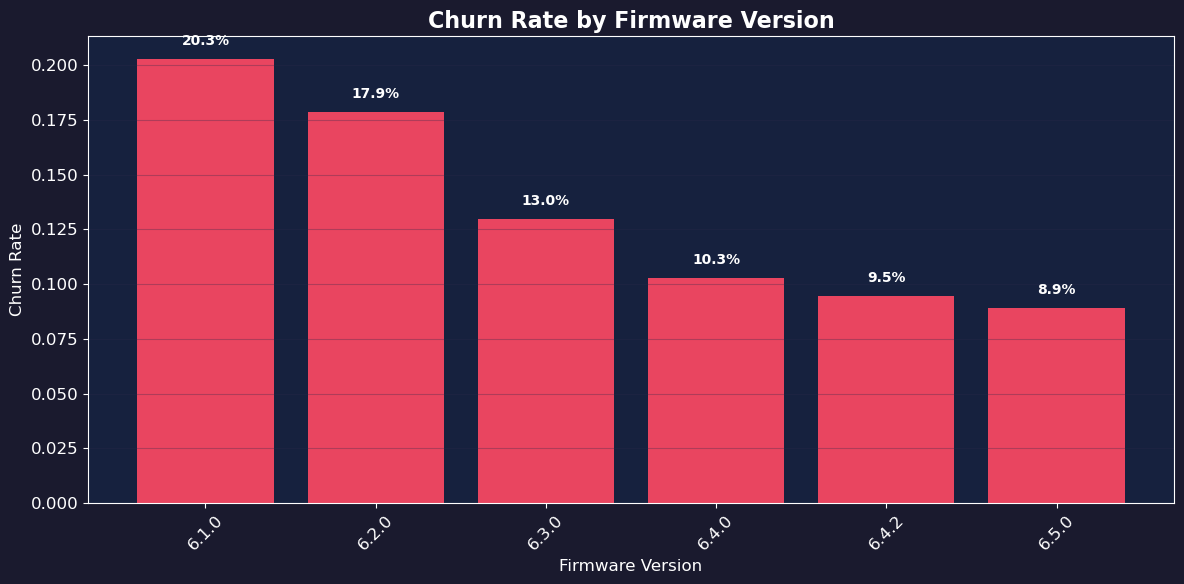

In [3]:
churn_by_fw = households.groupby('firmware_version')['churned'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(churn_by_fw.index.astype(str), churn_by_fw.values, color=PRIMARY, edgecolor='none')

# Value labels on bars
for bar, val in zip(bars, churn_by_fw.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.1%}', ha='center', va='bottom', fontsize=10, color=TEXT, fontweight='bold')

ax.set_xlabel('Firmware Version')
ax.set_ylabel('Churn Rate')
ax.set_title('Churn Rate by Firmware Version', fontsize=16, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/churn_rate_by_firmware.png', facecolor=BG, dpi=300, bbox_inches='tight')
plt.show()

## 2. Connection Drops Over Time

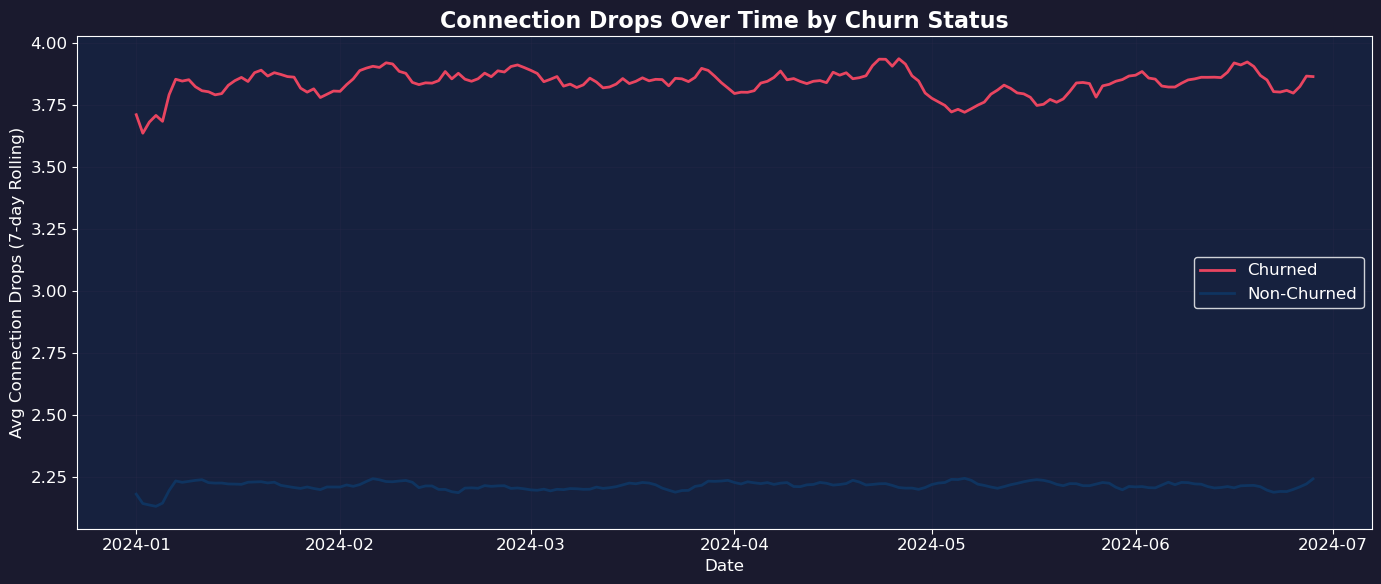

In [4]:
# Merge churn status into events
events_with_churn = events.merge(households[['household_id', 'churned']], on='household_id', how='left')

# Average daily connection drops by churn status
daily_drops = (
    events_with_churn
    .groupby(['date', 'churned'])['connection_drops']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

for label, color, churn_val in [('Churned', PRIMARY, 1), ('Non-Churned', SECONDARY, 0)]:
    subset = daily_drops[daily_drops['churned'] == churn_val].sort_values('date')
    rolling = subset.set_index('date')['connection_drops'].rolling(window=7, min_periods=1).mean()
    ax.plot(rolling.index, rolling.values, color=color, label=label, linewidth=2)

ax.set_xlabel('Date')
ax.set_ylabel('Avg Connection Drops (7-day Rolling)')
ax.set_title('Connection Drops Over Time by Churn Status', fontsize=16, fontweight='bold')
ax.legend()
ax.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/connection_drops_over_time.png', facecolor=BG, dpi=300, bbox_inches='tight')
plt.show()

## 3. Feature Adoption vs Retention

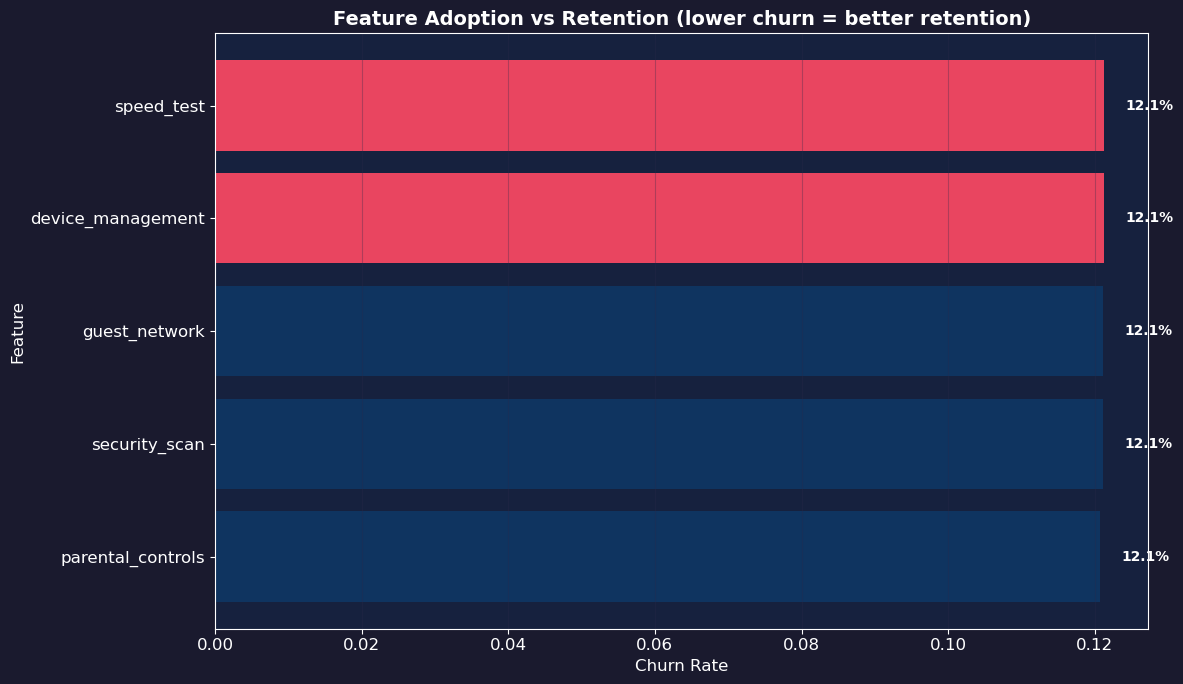

In [5]:
# For each feature, find which households used it, then compute churn rate
feature_households = sessions.groupby('feature_used')['household_id'].apply(set).to_dict()

feature_churn = {}
for feature, hh_set in feature_households.items():
    mask = households['household_id'].isin(hh_set)
    feature_churn[feature] = households.loc[mask, 'churned'].mean()

fc_series = pd.Series(feature_churn).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = [PRIMARY if v > fc_series.median() else SECONDARY for v in fc_series.values]
bars = ax.barh(fc_series.index, fc_series.values, color=colors, edgecolor='none')

# Value labels
for bar, val in zip(bars, fc_series.values):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.1%}', va='center', fontsize=10, color=TEXT, fontweight='bold')

ax.set_xlabel('Churn Rate')
ax.set_ylabel('Feature')
ax.set_title('Feature Adoption vs Retention (lower churn = better retention)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/feature_adoption_vs_retention.png', facecolor=BG, dpi=300, bbox_inches='tight')
plt.show()

## 4. Latency Distribution by Device Model

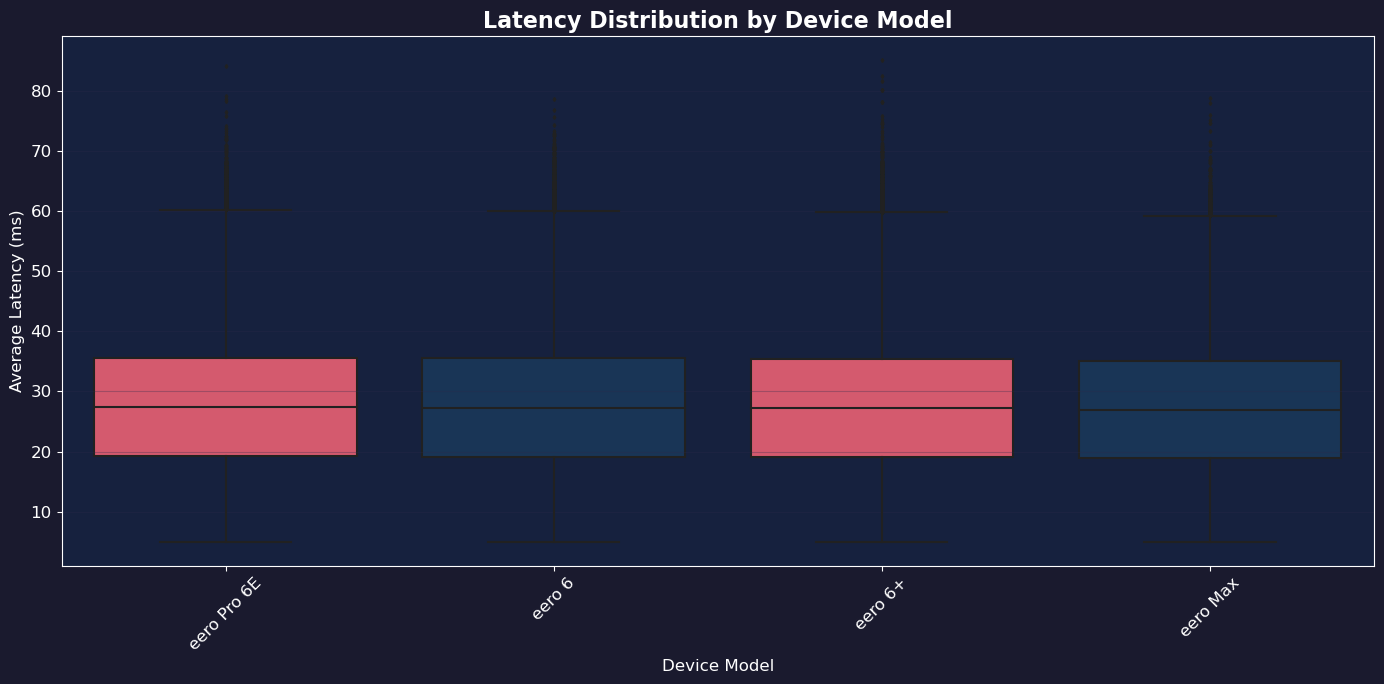

In [6]:
# Merge device model into events
events_with_model = events.merge(households[['household_id', 'device_model']], on='household_id', how='left')

# Order by median latency
model_order = (
    events_with_model.groupby('device_model')['avg_latency_ms']
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(14, 7))

palette = {model: PRIMARY if i % 2 == 0 else SECONDARY for i, model in enumerate(model_order)}
sns.boxplot(
    data=events_with_model,
    x='device_model',
    y='avg_latency_ms',
    order=model_order,
    palette=palette,
    fliersize=2,
    ax=ax,
)

ax.set_xlabel('Device Model')
ax.set_ylabel('Average Latency (ms)')
ax.set_title('Latency Distribution by Device Model', fontsize=16, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/latency_distribution_by_model.png', facecolor=BG, dpi=300, bbox_inches='tight')
plt.show()

## 5. Support Tickets vs Churn

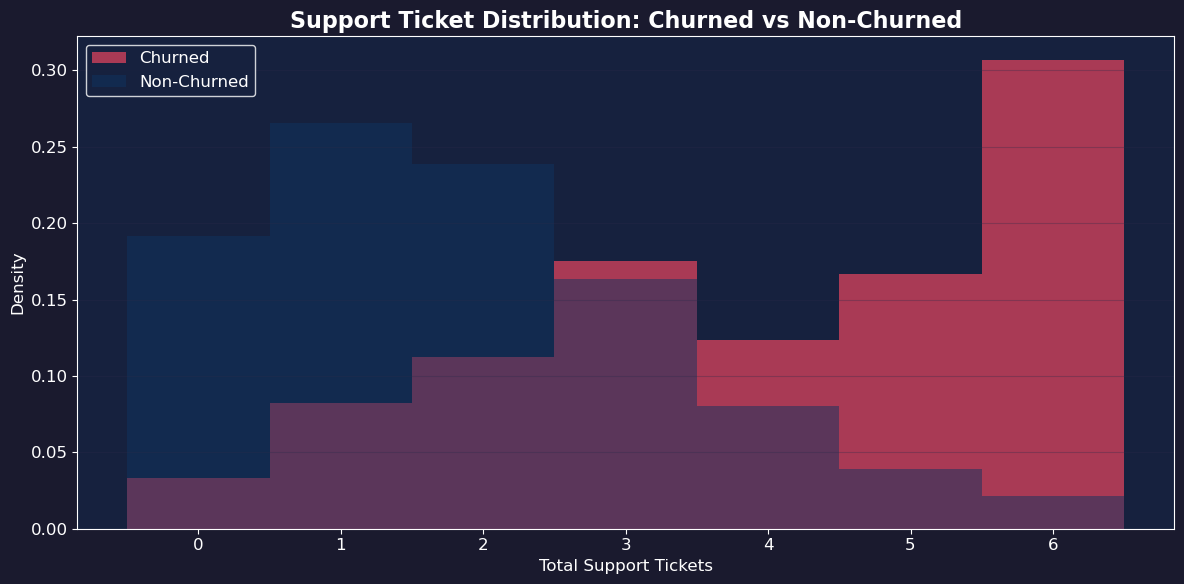

In [7]:
# Total support tickets per household
tickets_per_hh = sessions.groupby('household_id')['support_ticket_raised'].sum().reset_index()
tickets_per_hh.columns = ['household_id', 'total_tickets']
tickets_merged = tickets_per_hh.merge(households[['household_id', 'churned']], on='household_id', how='left')

# Cap at a reasonable max for readability
max_tickets = int(tickets_merged['total_tickets'].quantile(0.95))
tickets_merged['total_tickets_capped'] = tickets_merged['total_tickets'].clip(upper=max_tickets)

fig, ax = plt.subplots(figsize=(12, 6))

bins = np.arange(0, max_tickets + 2) - 0.5

churned_data = tickets_merged.loc[tickets_merged['churned'] == 1, 'total_tickets_capped']
retained_data = tickets_merged.loc[tickets_merged['churned'] == 0, 'total_tickets_capped']

ax.hist(churned_data, bins=bins, alpha=0.7, color=PRIMARY, label='Churned', density=True, edgecolor='none')
ax.hist(retained_data, bins=bins, alpha=0.5, color=SECONDARY, label='Non-Churned', density=True, edgecolor='none')

ax.set_xlabel('Total Support Tickets')
ax.set_ylabel('Density')
ax.set_title('Support Ticket Distribution: Churned vs Non-Churned', fontsize=16, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/support_tickets_vs_churn.png', facecolor=BG, dpi=300, bbox_inches='tight')
plt.show()

## 6. Regional Churn Heatmap

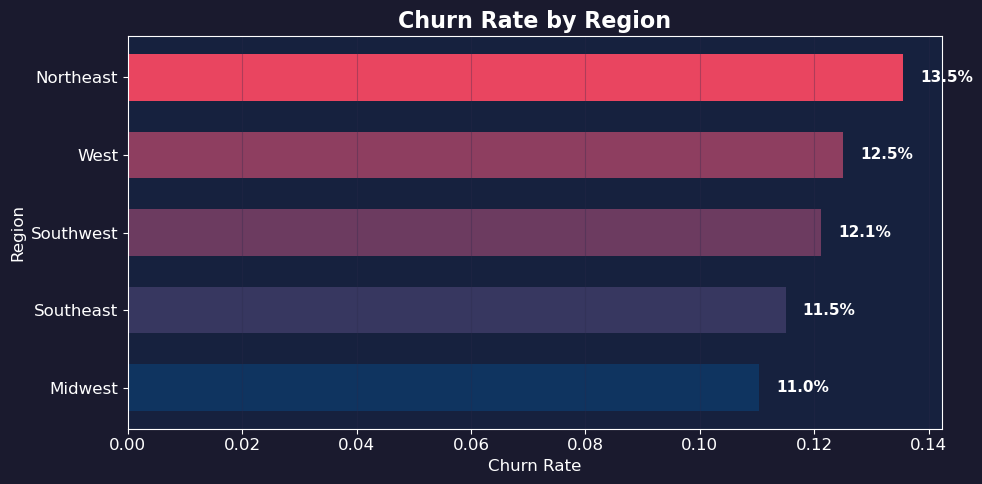

In [8]:
churn_by_region = households.groupby('region')['churned'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

# Color bars on a gradient from SECONDARY (low churn) to PRIMARY (high churn)
norm = plt.Normalize(churn_by_region.min(), churn_by_region.max())
cmap = matplotlib.colors.LinearSegmentedColormap.from_list('churn_cmap', [SECONDARY, PRIMARY])
bar_colors = [cmap(norm(v)) for v in churn_by_region.values]

bars = ax.barh(churn_by_region.index, churn_by_region.values, color=bar_colors, edgecolor='none', height=0.6)

# Value labels
for bar, val in zip(bars, churn_by_region.values):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.1%}', va='center', fontsize=11, color=TEXT, fontweight='bold')

ax.set_xlabel('Churn Rate')
ax.set_ylabel('Region')
ax.set_title('Churn Rate by Region', fontsize=16, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/regional_churn_heatmap.png', facecolor=BG, dpi=300, bbox_inches='tight')
plt.show()

## Key Takeaways

In [9]:
# ---------- Compute summary metrics ----------
overall_churn = households['churned'].mean()

# Firmware with highest churn
fw_churn = households.groupby('firmware_version')['churned'].mean()
worst_fw = fw_churn.idxmax()
worst_fw_rate = fw_churn.max()
best_fw = fw_churn.idxmin()
best_fw_rate = fw_churn.min()

# Avg connection drops: churned vs not
drops_churned = events_with_churn.loc[events_with_churn['churned'] == 1, 'connection_drops'].mean()
drops_retained = events_with_churn.loc[events_with_churn['churned'] == 0, 'connection_drops'].mean()

# Feature with lowest churn
best_feature = fc_series.idxmin()
best_feature_rate = fc_series.min()
worst_feature = fc_series.idxmax()
worst_feature_rate = fc_series.max()

# Avg tickets: churned vs not
avg_tickets_churned = tickets_merged.loc[tickets_merged['churned'] == 1, 'total_tickets'].mean()
avg_tickets_retained = tickets_merged.loc[tickets_merged['churned'] == 0, 'total_tickets'].mean()

# Region with highest churn
worst_region = churn_by_region.idxmax()
worst_region_rate = churn_by_region.max()

print('=' * 60)
print('KEY TAKEAWAYS')
print('=' * 60)
print(f'\n1. OVERALL CHURN RATE: {overall_churn:.2%}')
print(f'\n2. FIRMWARE IMPACT:')
print(f'   - Highest churn: {worst_fw} ({worst_fw_rate:.2%})')
print(f'   - Lowest churn:  {best_fw} ({best_fw_rate:.2%})')
print(f'\n3. CONNECTION DROPS (avg per day):')
print(f'   - Churned households:     {drops_churned:.2f}')
print(f'   - Non-churned households: {drops_retained:.2f}')
print(f'\n4. FEATURE ADOPTION:')
print(f'   - Best retention feature:  {best_feature} (churn {best_feature_rate:.2%})')
print(f'   - Worst retention feature: {worst_feature} (churn {worst_feature_rate:.2%})')
print(f'\n5. SUPPORT TICKETS (avg per household):')
print(f'   - Churned:     {avg_tickets_churned:.1f}')
print(f'   - Non-churned: {avg_tickets_retained:.1f}')
print(f'\n6. REGIONAL CHURN:')
print(f'   - Highest churn region: {worst_region} ({worst_region_rate:.2%})')
print(f'\n' + '=' * 60)

KEY TAKEAWAYS

1. OVERALL CHURN RATE: 12.12%

2. FIRMWARE IMPACT:
   - Highest churn: 6.1.0 (20.30%)
   - Lowest churn:  6.5.0 (8.91%)

3. CONNECTION DROPS (avg per day):
   - Churned households:     3.84
   - Non-churned households: 2.22

4. FEATURE ADOPTION:
   - Best retention feature:  parental_controls (churn 12.07%)
   - Worst retention feature: speed_test (churn 12.12%)

5. SUPPORT TICKETS (avg per household):
   - Churned:     4.5
   - Non-churned: 1.9

6. REGIONAL CHURN:
   - Highest churn region: Northeast (13.55%)

